# Kaggle dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests")

print("Path to dataset files:", path)
pd.read_csv(f'{path}//raw_analyst_ratings.csv').to_csv('raw_analyst_ratings.csv',index=False)
pd.read_csv(f'{path}//raw_partner_headlines.csv').to_csv('raw_partner_headlines.csv',index=False)
pd.read_csv(f'{path}//analyst_ratings_processed.csv').to_csv('analyst_ratings_processed.csv',index=False)

# Cell A — Load and filter to our 20 tickers

In [1]:
import pandas as pd

df_raw = pd.read_csv("raw_partner_headlines.csv", 
                     usecols=["headline","date","stock"])

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw = df_raw[df_raw["date"] >= "2019-01-01"].copy()
df_raw = df_raw[df_raw["date"] <= "2020-06-04"].copy()

print(f"Rows after date filter: {len(df_raw)}")
print(f"Date range: {df_raw['date'].min()} → {df_raw['date'].max()}")

well_covered = df_raw['stock'].value_counts()
well_covered = well_covered[well_covered >= 500]
print(f"\nTickers with 500+ headlines: {len(well_covered)}")
print(well_covered.head(30))

Rows after date filter: 464917
Date range: 2019-01-01 00:00:00 → 2020-06-04 00:00:00

Tickers with 500+ headlines: 96
stock
RSP      2655
JPM      2374
SLV      2285
INTC     2161
GCC      1741
TZA      1673
UDN      1458
SRTY     1294
NE       1278
HD       1262
KEY      1227
GILD     1214
VGIT     1210
LLY      1109
OXY      1029
XLE      1002
INDA      994
AVGO      971
DIS       933
VNQ       914
XLK       907
FDX       875
RDS.A     860
WBA       844
MDT       843
INDY      824
LUV       811
SGOL      793
FCAU      791
XLU       779
Name: count, dtype: int64


# Cell B — Sample up to 5 headlines per ticker per day

In [2]:
clean_tickers = [
    "JPM","INTC","HD","KEY","GILD","LLY",
    "OXY","AVGO","DIS","FDX","MDT","LUV","WBA"
]

prices_new = pd.read_csv("stock_prices_new.csv",index_col=False)
df_clean = df_raw[df_raw["stock"].isin(clean_tickers)].copy()
print(f"Total rows: {len(df_clean)}")
print(f"Tickers: {df_clean['stock'].nunique()}")
print(df_clean["stock"].value_counts())
print(f"\nDate range: {df_clean['date'].min()} → {df_clean['date'].max()}")

clean_tickers = [t for t in clean_tickers if t != "WBA"]
df_clean = df_clean[df_clean["stock"] != "WBA"].copy()
prices_new = prices_new.drop(columns=["WBA"])

print("\nPrices preview:")
print(prices_new.head(3))
print("Price columns:", prices_new.columns.tolist())

Total rows: 15653
Tickers: 13
stock
JPM     2374
INTC    2161
HD      1262
KEY     1227
GILD    1214
LLY     1109
OXY     1029
AVGO     971
DIS      933
FDX      875
WBA      844
MDT      843
LUV      811
Name: count, dtype: int64

Date range: 2019-01-01 00:00:00 → 2020-06-04 00:00:00

Prices preview:
         Date       AVGO         DIS         FDX       GILD          HD  \
0  2019-01-02  21.003382  105.177475  143.170822  48.178082  144.203720   
1  2019-01-03  19.135109  102.629349  137.906876  49.552639  141.025452   
2  2019-01-04  19.323177  105.795197  144.258698  51.830917  145.215790   

        INTC        JPM        KEY         LLY        LUV        MDT  \
0  40.518059  81.250206  10.640896  104.341850  42.916737  72.435631   
1  38.289040  80.095512  10.676317  101.099335  41.523808  70.400627   
2  40.638527  83.048256  11.037626  104.142044  43.572231  72.608635   

         OXY  
0  52.724865  
1  52.078571  
2  53.753868  
Price columns: ['Date', 'AVGO', 'DIS', 'FDX', '

In [3]:
df_sampled = (
    df_clean
    .sort_values(["stock","date"])
    .groupby(["stock","date"])
    .head(5)
    .reset_index(drop=True)
)

print(f"Columns: {df_sampled.columns.tolist()}")
print(f"Sampled rows: {len(df_sampled)}")
print(f"Unique ticker-date pairs: {df_sampled.groupby(['stock','date']).ngroups}")
df_sampled.head()

Columns: ['headline', 'date', 'stock']
Sampled rows: 11405
Unique ticker-date pairs: 4170


,headline,date,stock
0,The Best Undervalued Dividend Stocks To Buy Fo...,2019-01-01,AVGO
1,Dow Jones Futures Tumble As Apple Warns: Big T...,2019-01-02,AVGO
2,Suppliers drop on Apple's warning,2019-01-02,AVGO
3,Dow Tumbles More Than 550 Points; Apple Sells ...,2019-01-03,AVGO
4,Between Weak iPhones And Ongoing Margin Challe...,2019-01-03,AVGO


# Cell C — Run FinBERT sentiment on sampled headlines

In [4]:
import torch
from transformers import pipeline
from tqdm import tqdm

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=0,
    top_k=None,
    model_kwargs={"use_safetensors": True}
)

def get_finbert_batch(texts, batch_size=64):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="FinBERT"):
        batch = texts[i:i+batch_size]
        outputs = finbert(batch, truncation=True, max_length=512)
        for out in outputs:
            scores = {d["label"]: d["score"] for d in out}
            results.append({
                "finbert_positive": scores.get("positive", 0),
                "finbert_negative": scores.get("negative", 0),
                "finbert_neutral":  scores.get("neutral",  0)
            })
    return results

fb_scores = get_finbert_batch(df_sampled["headline"].tolist())
df_fb = pd.DataFrame(fb_scores)
df_sampled_fb = pd.concat([df_sampled.reset_index(drop=True), df_fb], axis=1)
df_sampled_fb.to_csv("news_with_finbert.csv", index=False)
print(f"Done. Shape: {df_sampled_fb.shape}")
print(df_sampled_fb.head(3))

/home/kevin/miniconda3/envs/idea2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3441.32it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
FinBERT: 100%|████████████████████████████████████████████████████████████████████████| 179/179 [00:52<00:00,  3.44it/s]

Done. Shape: (11405, 6)
                                            headline       date stock  \
0  The Best Undervalued Dividend Stocks To Buy Fo... 2019-01-01  AVGO   
1  Dow Jones Futures Tumble As Apple Warns: Big T... 2019-01-02  AVGO   
2                  Suppliers drop on Apple's warning 2019-01-02  AVGO   

   finbert_positive  finbert_negative  finbert_neutral  
0          0.431155          0.010672         0.558173  
1          0.029650          0.821219         0.149131  
2          0.012967          0.954279         0.032754  


# Cell D — Run Mistral sentiment

In [5]:
import requests, json, re, os
from tqdm import tqdm

def get_ollama_sentiment(headline, model="mistral"):
    prompt = f"""Analyze the financial sentiment of this news headline.
Respond with ONLY a JSON object: {{"positive": float, "negative": float, "neutral": float}}
All three values must sum to 1.0. No explanation, just the JSON.
Headline: {headline}"""
    try:
        r = requests.post("http://localhost:11434/api/generate", json={
            "model": model, "prompt": prompt,
            "stream": False, "options": {"temperature": 0.1}
        }, timeout=30)
        match = re.search(r'\{.*?\}', r.json()["response"], re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    return {"positive": 0.33, "negative": 0.33, "neutral": 0.34}

checkpoint = "news_with_mistral.csv"
start_idx = 0
mistral_scores = []

if os.path.exists(checkpoint):
    existing = pd.read_csv(checkpoint)
    mistral_scores = existing.to_dict("records")
    start_idx = len(mistral_scores)
    print(f"Resuming from row {start_idx}")

headlines = df_sampled["headline"].tolist()

for h in tqdm(headlines[start_idx:], desc="Mistral"):
    s = get_ollama_sentiment(h, model="mistral")
    mistral_scores.append({
        "mistral_positive": s.get("positive", 0.33),
        "mistral_negative": s.get("negative", 0.33),
        "mistral_neutral":  s.get("neutral",  0.34)
    })
    if len(mistral_scores) % 500 == 0:
        pd.DataFrame(mistral_scores).to_csv(checkpoint, index=False)

pd.DataFrame(mistral_scores).to_csv(checkpoint, index=False)
print(f"Done. {len(mistral_scores)} rows saved.")

Mistral: 100%|██████████████████████████████████████████████████████████████████| 11405/11405 [2:02:28<00:00,  1.55it/s]

Done. 11405 rows saved.


# Cell E —  All sentiment scores + aggregate daily

In [6]:
df_base = pd.read_csv("news_with_finbert.csv", parse_dates=["date"])
df_mi   = pd.read_csv("news_with_mistral.csv")

df_full = pd.concat([df_base.reset_index(drop=True),
                     df_mi.reset_index(drop=True)], axis=1)

# Aggregate: mean sentiment per ticker per day
sent_cols = [
    "finbert_positive","finbert_negative","finbert_neutral",
    "mistral_positive","mistral_negative","mistral_neutral"
]

df_daily_sent = (
    df_full
    .groupby(["stock","date"])[sent_cols]
    .mean()
    .reset_index()
)

df_daily_sent.to_csv("daily_sentiment_by_ticker.csv", index=False)
print(f"Daily sentiment shape: {df_daily_sent.shape}")
print(df_daily_sent.head(5))

Daily sentiment shape: (4170, 8)
  stock       date  finbert_positive  finbert_negative  finbert_neutral  \
0  AVGO 2019-01-01          0.431155          0.010672         0.558173   
1  AVGO 2019-01-02          0.021308          0.887749         0.090943   
2  AVGO 2019-01-03          0.024395          0.934302         0.041303   
3  AVGO 2019-01-04          0.279087          0.059531         0.661383   
4  AVGO 2019-01-05          0.888941          0.046166         0.064893   

   mistral_positive  mistral_negative  mistral_neutral  
0              0.75             0.100            0.150  
1              0.20             0.750            0.050  
2              0.15             0.775            0.075  
3              0.39             0.410            0.200  
4              0.85             0.100            0.050  


# Cell F — Merge sentiment with technical indicators:

In [8]:
import pandas as pd
import numpy as np

prices_new = pd.read_csv("stock_prices_new.csv", parse_dates=["Date"], index_col="Date")

def compute_indicators(series):
    df = pd.DataFrame({"close": series}).dropna()
    df["return_1d"] = df["close"].pct_change(1)
    df["return_5d"] = df["close"].pct_change(5)
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    df["rsi"] = 100 - (100 / (1 + gain / loss))
    ema12 = df["close"].ewm(span=12).mean()
    ema26 = df["close"].ewm(span=26).mean()
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    sma20 = df["close"].rolling(20).mean()
    std20 = df["close"].rolling(20).std()
    df["bb_position"] = (df["close"] - (sma20 - 2*std20)) / (4*std20)
    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
    return df

all_indicators = []
for ticker in prices_new.columns:
    ind = compute_indicators(prices_new[ticker]).dropna()
    ind["ticker"] = ticker
    ind["date"] = ind.index
    all_indicators.append(ind.rename(columns={"ticker":"stock"}))

df_technical_new = pd.concat(all_indicators, ignore_index=True)
df_technical_new.to_csv("technical_new.csv", index=False)
print(f"Technical indicators shape: {df_technical_new.shape}")
print(df_technical_new["stock"].value_counts())
print(df_technical_new.tail(3))

Technical indicators shape: (4080, 11)
stock
AVGO    340
DIS     340
FDX     340
GILD    340
HD      340
INTC    340
JPM     340
KEY     340
LLY     340
LUV     340
MDT     340
OXY     340
Name: count, dtype: int64
          close  return_1d  return_5d        rsi      macd  macd_signal  \
4077  13.804681   0.068066   0.024306  50.998804 -0.214654    -0.236625   
4078  14.459819   0.047458   0.071428  62.453540 -0.101688    -0.209637   
4079  14.553412   0.006473   0.140029  61.401288 -0.004557    -0.168621   

      macd_hist  bb_position  target stock       date  
4077   0.021970     0.689686       1   OXY 2020-06-02  
4078   0.107949     0.945659       1   OXY 2020-06-03  
4079   0.164064     0.925620       0   OXY 2020-06-04  


# Cell 14

In [10]:
import pandas as pd

df_technical = pd.read_csv("technical_new.csv", parse_dates=["date"])
df_daily_sent = pd.read_csv("daily_sentiment_by_ticker.csv", parse_dates=["date"])

df_daily_sent["date"] = pd.to_datetime(df_daily_sent["date"]).dt.normalize()
df_technical["date"] = pd.to_datetime(df_technical["date"]).dt.normalize()

df_fusion = df_technical.merge(
    df_daily_sent, on=["stock", "date"], how="inner"
)

df_fusion = df_fusion.dropna()
print(f"Fusion dataset shape: {df_fusion.shape}")
print(f"Date range: {df_fusion['date'].min()} → {df_fusion['date'].max()}")
print(f"Tickers: {df_fusion['stock'].nunique()}")
print(f"Class balance: {df_fusion['target'].value_counts().to_dict()}")
df_fusion.to_csv("fusion_news_technical.csv", index=False)
print("Saved: fusion_news_technical.csv")
print(df_fusion.head(3))

Fusion dataset shape: (3218, 17)
Date range: 2019-01-30 00:00:00 → 2020-06-04 00:00:00
Tickers: 12
Class balance: {1: 1699, 0: 1519}
Saved: fusion_news_technical.csv
       close  return_1d  return_5d        rsi      macd  macd_signal  \
0  22.437523   0.016897   0.051647  77.911862  0.338948     0.248935   
1  22.224594  -0.009490   0.017834  71.633201  0.343146     0.267953   
2  22.105289  -0.005368  -0.004217  68.589812  0.334306     0.281322   

   macd_hist  bb_position  target stock       date  finbert_positive  \
0   0.090013     0.873113       0  AVGO 2019-01-30          0.470212   
1   0.075193     0.791207       0  AVGO 2019-01-31          0.044666   
2   0.052984     0.744446       1  AVGO 2019-02-01          0.094198   

   finbert_negative  finbert_neutral  mistral_positive  mistral_negative  \
0          0.101806         0.427982          0.583333          0.216667   
1          0.025157         0.930176          0.250000          0.250000   
2          0.471538         

# Cell G — Train and evaluate fusion models:

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
import xgboost as xgb
import pandas as pd
import numpy as np

df_fusion = pd.read_csv("fusion_news_technical.csv", parse_dates=["date"])
df_fusion = df_fusion.sort_values("date")

cutoff_idx = int(len(df_fusion) * 0.8)
cutoff_date = df_fusion.iloc[cutoff_idx]["date"]

df_train = df_fusion[df_fusion["date"] < cutoff_date].copy()
df_test  = df_fusion[df_fusion["date"] >= cutoff_date].copy()

technical_features = ["return_1d","return_5d","rsi","macd",
                      "macd_signal","macd_hist","bb_position"]
finbert_features   = ["finbert_positive","finbert_negative","finbert_neutral"]
mistral_features   = ["mistral_positive","mistral_negative","mistral_neutral"]
all_sentiment      = finbert_features + mistral_features

feature_sets = {
    "Technical only":       technical_features,
    "FinBERT only":         finbert_features,
    "Mistral only":         mistral_features,
    "Tech + FinBERT":       technical_features + finbert_features,
    "Tech + Mistral":       technical_features + mistral_features,
    "Tech + All Sentiment": technical_features + all_sentiment,
}

y_train = df_train["target"]
y_test  = df_test["target"]

results = []
for fname, features in feature_sets.items():
    X_train = df_train[features]
    X_test  = df_test[features]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    models = {
        "LogReg":  LogisticRegression(max_iter=1000),
        "RF":      RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42,
                                      eval_metric="logloss")
    }

    for mname, model in models.items():
        if mname == "LogReg":
            model.fit(X_tr_sc, y_train)
            preds = model.predict(X_te_sc)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)

        results.append({
            "Feature Set": fname, "Model": mname,
            "Accuracy": round(accuracy_score(y_test, preds), 4),
            "F1":       round(f1_score(y_test, preds), 4),
            "MCC":      round(matthews_corrcoef(y_test, preds), 4)
        })
        print(f"{fname} | {mname} → "
              f"Acc:{results[-1]['Accuracy']} "
              f"F1:{results[-1]['F1']} "
              f"MCC:{results[-1]['MCC']}")

df_results = pd.DataFrame(results)
df_results.to_csv("fusion_model_results.csv", index=False)
print("\n=== TOP 10 BY MCC ===")
print(df_results.sort_values("MCC", ascending=False).head(10).to_string(index=False))

Technical only | LogReg → Acc:0.447 F1:0.5775 MCC:-0.1524
Technical only | RF → Acc:0.4747 F1:0.4502 MCC:-0.0476
Technical only | XGBoost → Acc:0.4762 F1:0.481 MCC:-0.0473
FinBERT only | LogReg → Acc:0.5146 F1:0.6795 MCC:0.0
FinBERT only | RF → Acc:0.5453 F1:0.5889 MCC:0.0868
FinBERT only | XGBoost → Acc:0.5115 F1:0.5546 MCC:0.0185
Mistral only | LogReg → Acc:0.4854 F1:0.6347 MCC:-0.0848
Mistral only | RF → Acc:0.4962 F1:0.5354 MCC:-0.0119
Mistral only | XGBoost → Acc:0.4854 F1:0.5275 MCC:-0.0339
Tech + FinBERT | LogReg → Acc:0.4363 F1:0.5677 MCC:-0.1772
Tech + FinBERT | RF → Acc:0.4962 F1:0.506 MCC:-0.008
Tech + FinBERT | XGBoost → Acc:0.4808 F1:0.5101 MCC:-0.0412
Tech + Mistral | LogReg → Acc:0.4654 F1:0.5877 MCC:-0.1037
Tech + Mistral | RF → Acc:0.4931 F1:0.4876 MCC:-0.0124
Tech + Mistral | XGBoost → Acc:0.4854 F1:0.5081 MCC:-0.0311
Tech + All Sentiment | LogReg → Acc:0.467 F1:0.5854 MCC:-0.0975
Tech + All Sentiment | RF → Acc:0.4992 F1:0.5105 MCC:-0.002
Tech + All Sentiment | XGBoo

# FIG 1

In [14]:
import pandas as pd

rows = [
    ("Technical only",       "LogReg",  0.4470, 0.5775, -0.1524),
    ("Technical only",       "RF",      0.4747, 0.4502, -0.0476),
    ("Technical only",       "XGBoost", 0.4762, 0.4810, -0.0473),
    ("FinBERT only",         "LogReg",  0.5146, 0.6795,  0.0000),
    ("FinBERT only",         "RF",      0.5453, 0.5889,  0.0868),
    ("FinBERT only",         "XGBoost", 0.5115, 0.5546,  0.0185),
    ("Mistral only",         "LogReg",  0.4854, 0.6347, -0.0848),
    ("Mistral only",         "RF",      0.4962, 0.5354, -0.0119),
    ("Mistral only",         "XGBoost", 0.4854, 0.5275, -0.0339),
    ("Tech + FinBERT",       "LogReg",  0.4363, 0.5677, -0.1772),
    ("Tech + FinBERT",       "RF",      0.4962, 0.5060, -0.0080),
    ("Tech + FinBERT",       "XGBoost", 0.4808, 0.5101, -0.0412),
    ("Tech + Mistral",       "LogReg",  0.4654, 0.5877, -0.1037),
    ("Tech + Mistral",       "RF",      0.4931, 0.4876, -0.0124),
    ("Tech + Mistral",       "XGBoost", 0.4854, 0.5081, -0.0311),
    ("Tech + All Sentiment", "LogReg",  0.4670, 0.5854, -0.0975),
    ("Tech + All Sentiment", "RF",      0.4992, 0.5105, -0.0020),
    ("Tech + All Sentiment", "XGBoost", 0.4777, 0.4895, -0.0451),
]

df_res = pd.DataFrame(rows, columns=["Feature Set","Model","Accuracy","F1","MCC"])
df_res.to_csv("fusion_model_results_clean.csv", index=False)
print("=== SORTED BY MCC (best first) ===")
print(df_res.sort_values("MCC", ascending=False).to_string(index=False))

=== SORTED BY MCC (best first) ===
         Feature Set   Model  Accuracy     F1     MCC
        FinBERT only      RF    0.5453 0.5889  0.0868
        FinBERT only XGBoost    0.5115 0.5546  0.0185
        FinBERT only  LogReg    0.5146 0.6795  0.0000
Tech + All Sentiment      RF    0.4992 0.5105 -0.0020
      Tech + FinBERT      RF    0.4962 0.5060 -0.0080
        Mistral only      RF    0.4962 0.5354 -0.0119
      Tech + Mistral      RF    0.4931 0.4876 -0.0124
      Tech + Mistral XGBoost    0.4854 0.5081 -0.0311
        Mistral only XGBoost    0.4854 0.5275 -0.0339
      Tech + FinBERT XGBoost    0.4808 0.5101 -0.0412
Tech + All Sentiment XGBoost    0.4777 0.4895 -0.0451
      Technical only XGBoost    0.4762 0.4810 -0.0473
      Technical only      RF    0.4747 0.4502 -0.0476
        Mistral only  LogReg    0.4854 0.6347 -0.0848
Tech + All Sentiment  LogReg    0.4670 0.5854 -0.0975
      Tech + Mistral  LogReg    0.4654 0.5877 -0.1037
      Technical only  LogReg    0.4470 0.5775 -

# FIG 2

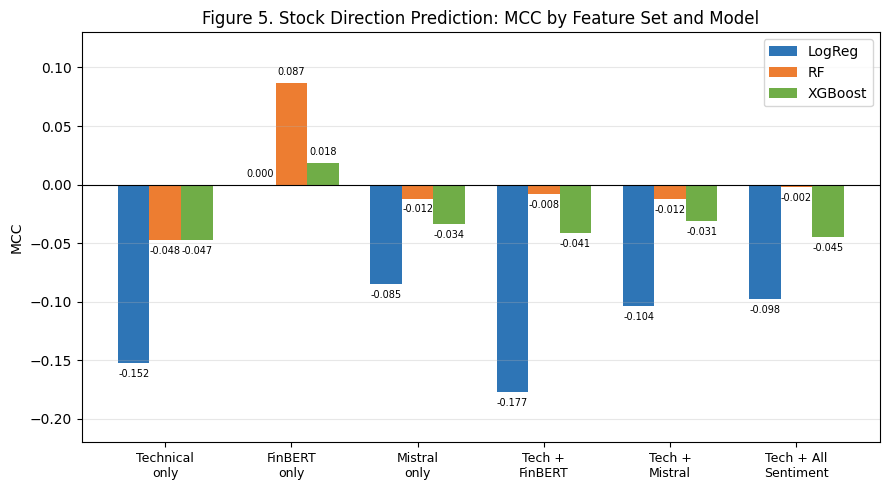

Figure 5 saved


In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))

feature_sets = ["Technical\nonly", "FinBERT\nonly", "Mistral\nonly",
                "Tech +\nFinBERT", "Tech +\nMistral", "Tech + All\nSentiment"]
logreg_mcc  = [-0.1524, 0.0,    -0.0848, -0.1772, -0.1037, -0.0975]
rf_mcc      = [-0.0476, 0.0868, -0.0119, -0.008,  -0.0124, -0.002]
xgb_mcc     = [-0.0473, 0.0185, -0.0339, -0.0412, -0.0311, -0.0451]

x = np.arange(len(feature_sets))
w = 0.25

b1 = ax.bar(x - w, logreg_mcc, w, label="LogReg",  color="#2E75B6")
b2 = ax.bar(x,     rf_mcc,     w, label="RF",       color="#ED7D31")
b3 = ax.bar(x + w, xgb_mcc,   w, label="XGBoost",  color="#70AD47")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        va = "bottom" if h >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width()/2,
                h + (0.005 if h >= 0 else -0.005),
                f"{h:.3f}", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_sets, fontsize=9)
ax.set_ylabel("MCC")
ax.set_title("Figure 5. Stock Direction Prediction: MCC by Feature Set and Model")
ax.legend()
ax.set_ylim(-0.22, 0.13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure5_fusion_mcc.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 5 saved")

# Fig 3

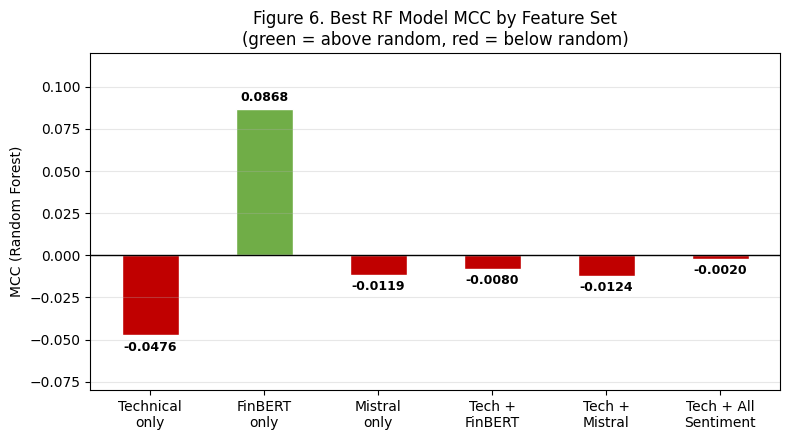

Figure 6 saved


In [15]:
import matplotlib.pyplot as plt
import numpy as np

labels  = ["Technical\nonly", "FinBERT\nonly", "Mistral\nonly",
           "Tech +\nFinBERT", "Tech +\nMistral", "Tech + All\nSentiment"]
mcc_rf  = [-0.0476, 0.0868, -0.0119, -0.0080, -0.0124, -0.0020]
colors  = ["#C00000" if v < 0 else "#70AD47" for v in mcc_rf]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, mcc_rf, color=colors, width=0.5, edgecolor="white")

for bar, v in zip(bars, mcc_rf):
    va = "bottom" if v >= 0 else "top"
    ax.text(bar.get_x() + bar.get_width()/2,
            v + (0.003 if v >= 0 else -0.003),
            f"{v:.4f}", ha="center", va=va, fontsize=9, fontweight="bold")

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("MCC (Random Forest)")
ax.set_title("Figure 6. Best RF Model MCC by Feature Set\n(green = above random, red = below random)")
ax.set_ylim(-0.08, 0.12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure6_rf_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 6 saved")